# Лабораторная работа № 1 — задание 1

> Выберите непрерывное распределение, у которого существуют первые четыре момента, и экспериментально убедитесь в асимптотической нормальности выборочного среднего, выборочной дисперсии, выборочной квантили порядка 0.5 для данного распределения. Также эмпирически убедитесь в том, что
>
> $$nF(X_{(k)}) \xrightarrow{d} U_1 \sim \Gamma(k,1), \qquad n\bigl(1-F(X_{(n+1-j)})\bigr) \xrightarrow{d} U_2 \sim \Gamma(j,1),$$
>
> где $k$ — целая часть среднего арифметического порядковых номеров первых букв фамилий членов команды, $j$ — аналогично, но используются первые буквы имён.
>
> **Указание.** Сгенерируйте достаточно большое количество выборок достаточно большого объёма, для каждой сгенерированной выборки вычислите соответствующие статистики (функции от выборок), постройте гистограммы результатов для каждой статистики. Для наглядности рядом с гистограммой можно нарисовать соответствующую плотность (пока это метод «на глаз», но в дальнейшем будет рассмотрена статистическая процедура проверки согласованности). Помимо гистограммы можно вывести математическое ожидание, дисперсию (или стандартное отклонение), медиану и другие описательные статистики.

## Вариант и выбранное распределение

Работу выполняют **Хасанов Дмитрий** и **Свешников Борис**: Х = 23, С = 19, Д = 5, Б = 2. Поэтому

$$k=\left\lfloor\frac{23+19}{2}\right\rfloor=21,\qquad j=\left\lfloor\frac{5+2}{2}\right\rfloor=3.$$

### Выбор распределения

Выберем **экспоненциальное распределение с $\lambda=1$**: $X\sim\operatorname{Exp}(1)$. Его плотность - $e^{-x} * 1(x \geq 0)$, а функция распределения - $(1 - e^{-x}) * 1(x \geq 0)$

### Вычисление моментов

Интегрируем по частям: $u=x^r$, $dv=e^{-x}\,dx$, $du=r x^{r-1}\,dx$ и $v=-e^{-x}$. Получаем

$$
\begin{aligned}
\mathbb E[X^r]
&=\int_0^{+\infty}x^r e^{-x}\,dx\\
&=\left[-x^r e^{-x}\right]_0^{+\infty}
+r\int_0^{+\infty}x^{r-1}e^{-x}\,dx\\
&=r\,\mathbb E[X^{r-1}].
\end{aligned}
$$

При $r = 0$ интеграл конечен:

$$
\mathbb E[1]=\int_0^{+\infty}e^{-x}\,dx
=\left[-e^{-x}\right]_0^{+\infty}=1.
$$

Получили, что  все первые четыре момента конечны (равны факториалам  номера момента), что и требовалось по условию.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from grafics.artifacts import save_figure

from generation.exponential import sample_exponential, less_F, greather_F
from grafics.plots import plot_gamma, plot_normal

ITERS = 10_000
SAMPLE_SIZES = (20, 100, 500)
ORDER_SIZES = (50, 200, 1_000)
K, J = 21, 3
rng = np.random.default_rng()


## 1. Асимптотическая нормальность статистик

Для каждого $n$ генерируем много независимых выборок. Внутри выборки $X_1,\ldots,X_n$ iid с распределением $\operatorname{Exp}(1)$. Для каждой выборки вычисляем три статистики:

$$
\overline X=\frac1n\sum_{i=1}^{n}X_i,\qquad
S_*^2=\frac1n\sum_{i=1}^{n}(X_i-\overline X_n)^2,\qquad
M=\operatorname{median}(X_1,\ldots,X_n).
$$

$\overline X$ — выборочное среднее, $S_*^2$ — выборочная дисперсия с делителем $n$, $M$ — выборочная медиана. При чётном $n$ медиана вычисляется как среднее двух центральных элементов упорядоченной выборки.

Асимптотическая нормальность оценки $T_n$ параметра $\theta$ записывается в виде

$$
\sqrt n(T_n-\theta)\xrightarrow{d}N(0,v),
$$

где $v$ — дисперсия предельного нормального закона, а его стандартное отклонение равно $\sqrt v$. Для сравнения с $N(0,1)$ делим левую часть на $\sqrt v$.

### 1.1. Выборочное среднее

На лекции показывали, что асимптотическая нормальность выборочного среднего имеет вид

$$
\sqrt n(\overline X-\mu)\xrightarrow{d}N(0,\sigma^2).
$$

Для Exp(1)

$$
\mu=\mathbb E[X]=1,\qquad
\sigma^2=\mathbb E[X^2]-(\mathbb E[X])^2=2-1=1.
$$

Следовательно,

$$
\boxed{\sqrt n(\overline X-1)\xrightarrow{d}N(0,1).}
$$

### 1.2. Выборочная дисперсия

При конечном четвёртом моменте

$$
\sqrt n(S_*^2-\sigma^2)\xrightarrow{d}N(0,\mu_4-\sigma^4),
\qquad \mu_4=\mathbb E[(X-\mu)^4].
$$

Для Exp(1) $\mu=1$, $\sigma^2=1$. Вычислим четвёртый центральный момент:

$$
\begin{aligned}
\mu_4
&=\mathbb E[(X-1)^4]\\
&=\mathbb E[X^4]-4\mathbb E[X^3]+6\mathbb E[X^2]-4\mathbb E[X]+1\\
&=24-4\cdot6+6\cdot2-4\cdot1+1=9.
\end{aligned}
$$

Поэтому

$$
\boxed{\sqrt n(S_*^2-1)\xrightarrow{d}N(0,9-1)=N(0,8).}
$$

Для сравнения со стандартной нормальной плотностью в коде делим на $\sqrt8$:

$$
\frac{\sqrt n(S_*^2-1)}{\sqrt8}\xrightarrow{d}N(0,1).
$$

### 1.3. Выборочная медиана

По теореме об асимптотике средних членов вариационного ряда, если $p(q_\alpha)>0$, тогда

$$
\sqrt n\,
p(q_\alpha),
\frac{X_{(\lceil n\alpha\rceil)}-q_\alpha}
{\sqrt{\alpha(1-\alpha)}}
\xrightarrow{d}N(0,1).
$$

Для медианы берём $\alpha=1/2$.

$$
F(q_{1/2})=1-e^{-q_{1/2}}=\frac12
\quad\Longrightarrow\quad
q_{1/2}=\ln2,\qquad
p(q_{1/2})=e^{-\ln2}=\frac12>0.
$$

Следовательно:

$$
\sqrt n\left(X_{(\lceil n/2\rceil)}-\ln2\right)
\xrightarrow{d}N(0,1).
$$

При нечётном $n$ член $X_{(\lceil n/2\rceil)}$ совпадает с выборочной медианой. При чётном $n$ в коде используется среднее двух центральных членов:

$$
M_n=\frac{X_{(n/2)}+X_{(n/2+1)}}2.
$$

Оно имеет ту же асимптотику, поэтому для используемой в эксперименте медианы

$$
\boxed{\sqrt n(M_n-\ln2)\xrightarrow{d}N(0,1).}
$$

### Графики

Для каждой выборки вычисляем три нормированные величины. По всем повторениям строим их гистограммы и накладываем плотность стандартного нормального распределения

При увеличении $n$ ожидается приближение формы гистограмм к этой кривой. 


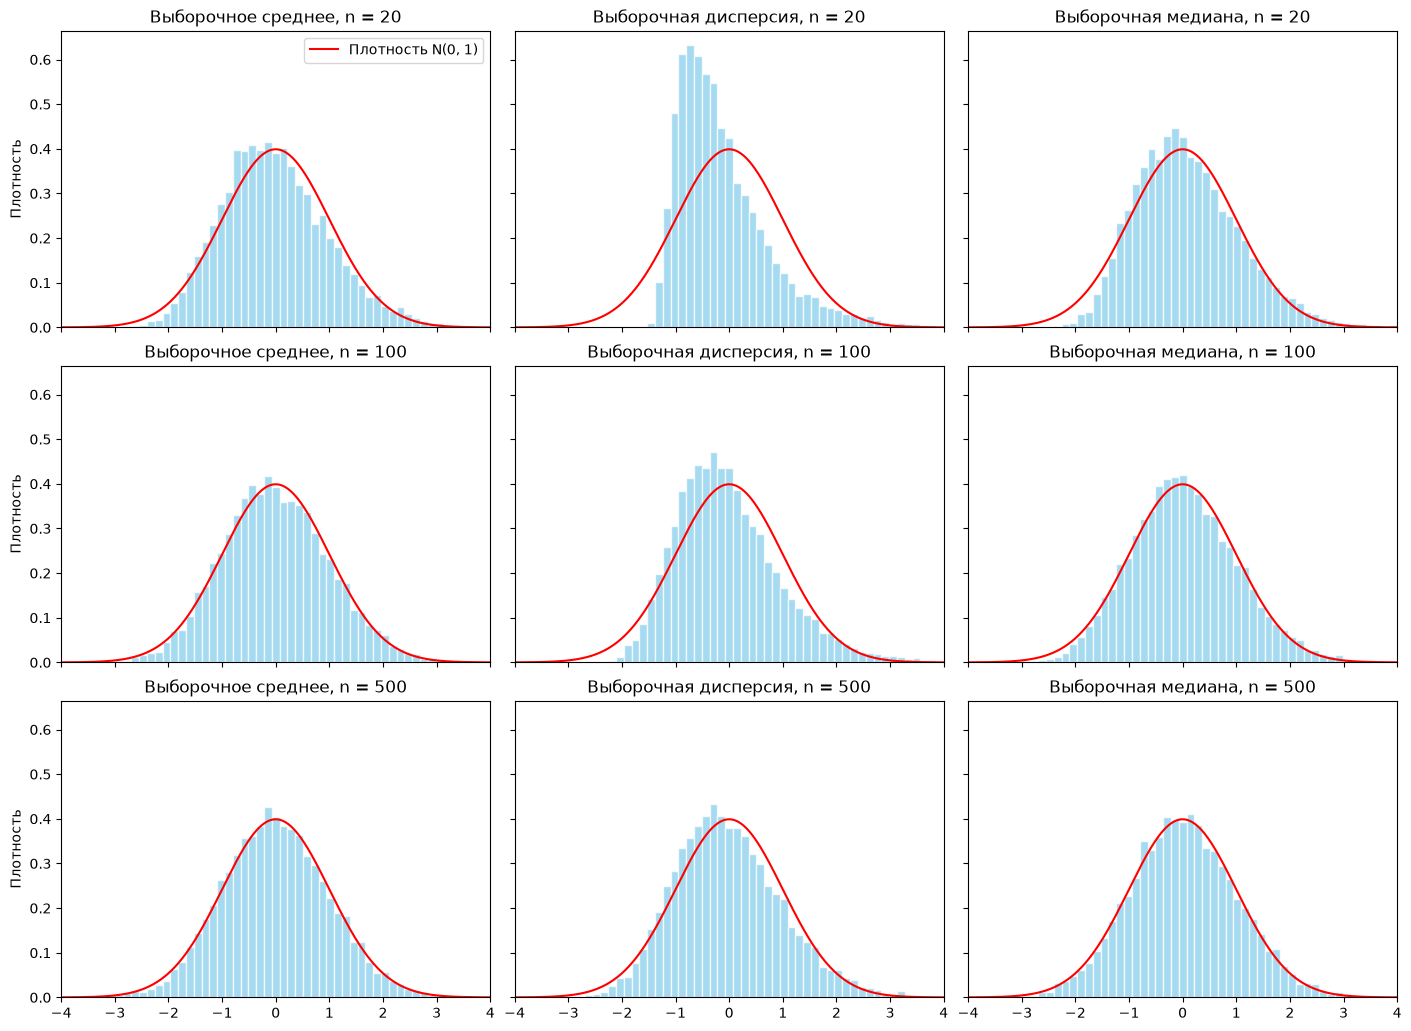

In [2]:
normal_results = {}
for n in SAMPLE_SIZES:
    samples = sample_exponential(rng, ITERS, n)
    mean = samples.mean(axis=1)
    variance = samples.var(axis=1, ddof=0)
    median = np.median(samples, axis=1)
    normal_results[n] = {
        "mean": np.sqrt(n) * (mean - 1),
        "variance": np.sqrt(n / 8) * (variance - 1),
        "median": np.sqrt(n) * (median - np.log(2)),
    }

fig = plot_normal(normal_results)
save_figure(fig, "task_1_normal.png")
plt.show()


## 2. Крайние порядковые статистики

Обозначим упорядоченную выборку через $X_{(1)}\leqslant\cdots\leqslant X_{(n)}$. Для наших $k=21$, $j=3$ считаем

$$A_n=nF(X_{(21)}),\qquad B_n=n\bigl[1-F(X_{(n-2)})\bigr].$$

Они в пределе $\Gamma(21,1)$ и $\Gamma(3,1)$ (доказали на практике). 

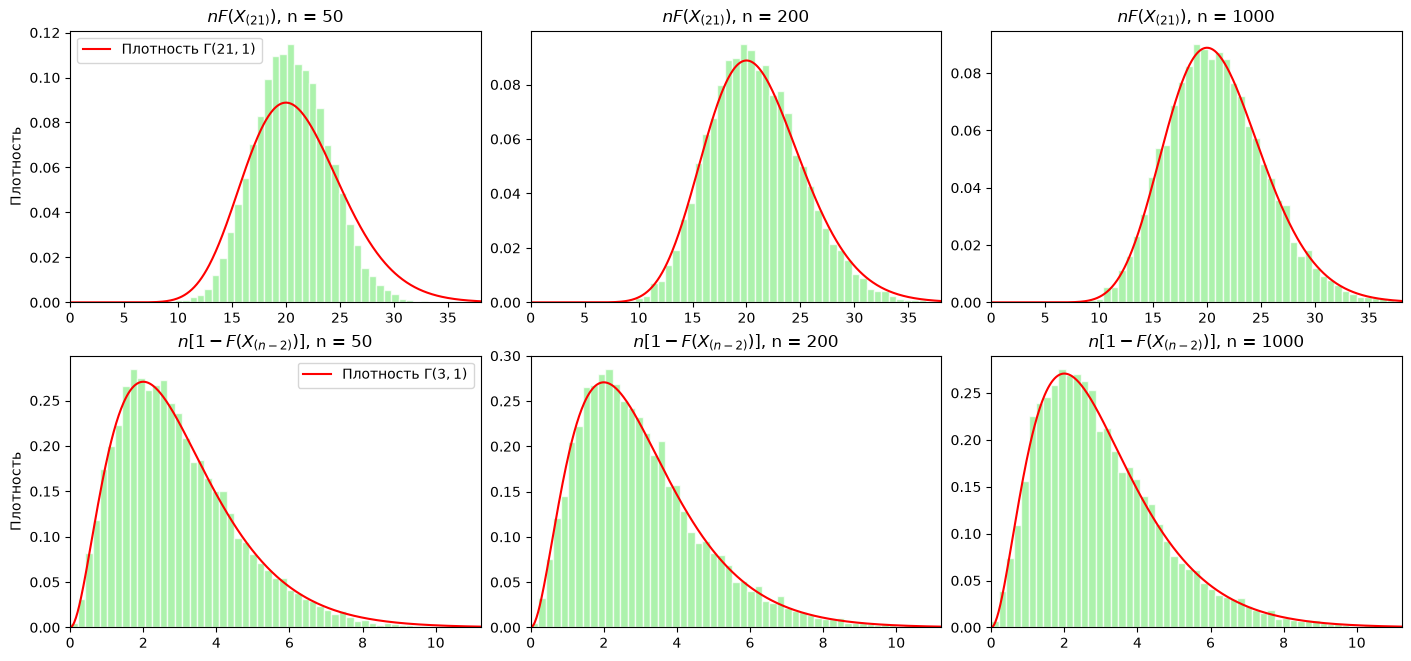

In [3]:
order_results = {}
for n in ORDER_SIZES:
    samples = sample_exponential(rng, ITERS, n)
    selected = np.partition(samples, (K - 1, n - J), axis=1)
    lower = selected[:, K - 1]
    upper = selected[:, n - J]
    order_results[n] = (n * less_F(lower), n * greather_F(upper))

fig = plot_gamma(order_results, K, J)
save_figure(fig, "task_1_gamma.png")
plt.show()


## Вывод

Мы эксперементально убедились в асимтотической нормальности выборочного среднего, выборочной медианы, выборочной медианы. Также эмперически убедились в корректности задачи 1.4.8 с практики. Графики позволяют убедится, что при стремлении $n$ к бесконечности распределения всё больше похоже на требуемые.